In [1]:
from pathlib import Path
import subprocess
import json

import openeo
import contextily
import shapely
import pystac
import pystac_client
import matplotlib.pyplot as plt
import rioxarray
import yaml

import notebook_utils as utils

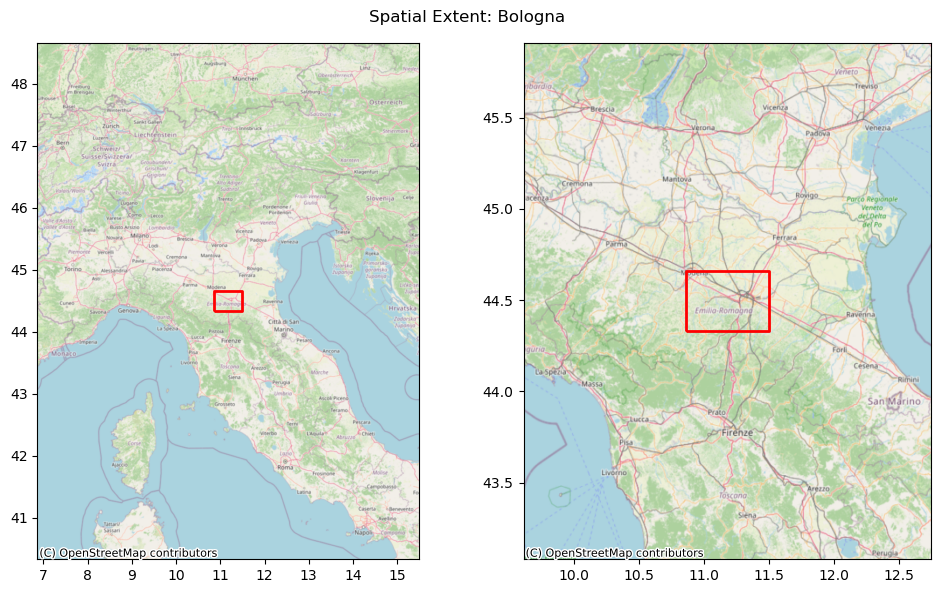

In [2]:
w,s,e,n = 10.864, 44.330, 11.497, 44.659 # This fails currently
spatial_extent = { "west": w, "south": s, "east": e, "north": n}
aoi_name = "Bologna"
#temporal_extent=["2026-03-01", "2026-03-31"]
temporal_extent=["2026-03-01", "2026-03-10"]

utils.plot_area_of_interest(
    w=w,
    s=s,
    e=e,
    n=n,
    large_context=4,
    figsize=(10, 6),
    title=f"Spatial Extent: {aoi_name}"
)

In [3]:
backend_url = "openeo-staging.dataspace.copernicus.eu"
connection = openeo.connect(backend_url).authenticate_oidc()

Authenticated using refresh token.


In [4]:
parameters_path = Path("../test/force-l2-full-params.yml").resolve()
parameters = yaml.safe_load(parameters_path.read_text())

del parameters["input"]

parameters

{'name': 'Full_parameter_test',
 'tile_size': 30000,
 'block_size': 3000,
 'origin_lon': -25.0,
 'origin_lat': 60.0,
 'resolution': 20,
 'projection': 'GLANCE7',
 'resampling': 'CC',
 'dem': 'Copernicus_30m',
 'do_atmo': True,
 'do_topo': True,
 'do_brdf': True,
 'do_adjacency': False,
 'do_multi_scattering': True,
 'do_aod': True,
 'erase_clouds': False,
 'max_cloud_cover_frame': 90,
 'max_cloud_cover_tile': 90,
 'cloud_buffer': 300,
 'cirrus_buffer': 30,
 'shadow_buffer': 90,
 'snow_buffer': 30,
 'cloud_threshold': 0.1,
 'shadow_threshold': 0.02,
 'res_merge': 'IMPROPHE',
 'impulse_noise': True,
 'buffer_nodata': False,
 'output_format': 'GTiff',
 'output_dst': False,
 'output_aod': False,
 'output_wvp': False,
 'output_vzn': False,
 'output_hot': False,
 'output_ovv': False}

In [5]:
L1C_COLLECTION_URL = "https://stac.dataspace.copernicus.eu/v1/collections/sentinel-2-l1c"

client = pystac_client.Client.open("https://stac.dataspace.copernicus.eu/v1")
search = client.search(
    datetime=temporal_extent,
    collections=["sentinel-2-l1c"],
    bbox=[w, s, e, n]
)
item_collection = search.item_collection()

print("Found items:")
for item in search.items():
    print(item.id)


Found items:
S2A_MSIL1C_20260310T101051_N0512_R022_T32TPQ_20260310T152637
S2C_MSIL1C_20260308T100851_N0512_R022_T32TPQ_20260308T142021
S2B_MSIL1C_20260303T101019_N0512_R022_T32TPQ_20260303T152416


In [6]:
# This is currently necessary to pass a longer list of inputs to FORCE level 2
catalog = utils.transform_item_collection_to_catalog_with_links(item_collection)
catalog

<Catalog id=item-collection-catalog>

In [7]:
cwl_root = Path("../cwl").resolve()
level2_res = subprocess.run(
    [
        "cwltool",
        "--pack",
        str(cwl_root / "force-l2-workflow.cwl"),
    ],
    capture_output=True
)
try:
    level2_res.check_returncode()
except subprocess.CalledProcessError as e:
    print("STDERR")
    print(level2_res.stderr.decode())
    raise e
cwl_level2 = level2_res.stdout.decode()

In [8]:
cwl_tree = json.loads(cwl_level2)

#print(cwl_tree)
[r for r in cwl_tree["$graph"][1]["requirements"] if r["class"] == "DockerRequirement"]

[{'dockerPull': 'quay.io/bcdev/force-eoap:0.0.16',
  'class': 'DockerRequirement'}]

In [9]:
context = dict(
    stac_document=catalog.to_dict(),
)

stac_resource = openeo.rest.stac_resource.StacResource(
    graph=openeo.internal.graph_building.PGNode(
        process_id="run_cwl_to_stac",
        arguments={
            "cwl": cwl_level2,
            "context": context,
        }
    ),
    connection=connection,
)
l2_job = stac_resource.create_job(title=f"FORCE level 2 - {aoi_name} - debug NPROC 1 NTHREAD 4")
print(f"Job id: '{l2_job.job_id}'")
l2_job.start()#_and_wait()

Job id: 'j-2604231422494b9a90464a3d1fbbd219'
0:00:00 Job 'j-2604231422494b9a90464a3d1fbbd219': send 'start'
0:00:13 Job 'j-2604231422494b9a90464a3d1fbbd219': created (progress 0%)
0:00:18 Job 'j-2604231422494b9a90464a3d1fbbd219': running (progress 2.7%)
0:00:25 Job 'j-2604231422494b9a90464a3d1fbbd219': running (progress 3.7%)
0:00:33 Job 'j-2604231422494b9a90464a3d1fbbd219': running (progress 5.0%)
0:00:43 Job 'j-2604231422494b9a90464a3d1fbbd219': running (progress 6.4%)
0:00:55 Job 'j-2604231422494b9a90464a3d1fbbd219': running (progress 8.2%)
0:01:11 Job 'j-2604231422494b9a90464a3d1fbbd219': running (progress 10.4%)
0:01:31 Job 'j-2604231422494b9a90464a3d1fbbd219': running (progress 13.0%)
0:02:38 Job 'j-2604231422494b9a90464a3d1fbbd219': running (progress 16.4%)
0:03:09 Job 'j-2604231422494b9a90464a3d1fbbd219': running (progress 23.7%)
0:03:47 Job 'j-2604231422494b9a90464a3d1fbbd219': running (progress 27.3%)
0:04:34 Job 'j-2604231422494b9a90464a3d1fbbd219': running (progress 31.2%)


OpenEoApiError: [500] Internal: Server error: EjrApiResponseError("Error communicating with the openEO job database system. For transient errors it might be enough to retry. Details: 502 'Bad Gateway' on `POST https://ejr-api-v2.eu-nl.openeo.v1.dataspace.copernicus.eu/jobs/search`: Bad Gateway") (ref: r-2604231507354d0ba008dc63645be207)

In [ ]:
l2_logs = l2_job.logs()

In [ ]:
[l.message for l in l2_logs[-260:-130]]

In [ ]:
l2_logs